<a href="https://colab.research.google.com/github/bimarshak7/liver-cirrhosis-prediction/blob/main/cirrhosis_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cirrhosis Prediction

**SCENARIO**  
Cirrhosis is a long-term liver disease that happens when healthy liver tissue gets replaced by scar tissue, causing a gradual loss of liver function. The scar tissue can block blood flow in the liver and prevent it from working properly. Cirrhosis can develop from several causes, including chronic hepatitis B or C, alcohol abuse, nonalcoholic fatty liver disease, and autoimmune disorders. Symptoms of cirrhosis may include fatigue, jaundice, itching, easy bruising, and swelling in the abdomen.

There is no cure for cirrhosis, but treatments can help manage symptoms and slow down the disease's progress. Diagnosing cirrhosis involves procedures like blood tests, reviewing medical history, physical exams, and imaging studies. The severe stages of cirrhosis are easy to identify, but by this point, the liver is badly damaged and cannot function properly.

Early diagnosis is crucial to protect the liver. A liver biopsy can detect cirrhosis at an early stage, but it requires an operation and takes time. Therefore, we need an intelligent system that can identify cirrhosis even earlier by using various biomarkers.

**PROBLEM STATEMENT**  
In this project, our aim is to recognize liver cirrhosis at different stages. We tackle this issue as a classification problem to identify cirrhosis across four stages (from 1 to 4) using different biomarkers.

**DATASET**  
The dataset used contains the information collected from the Mayo Clinic trial in primary biliary cirrhosis (PBC) of the liver conducted between 1974 and 1984.
A total of 424 PBC patients, referred to Mayo Clinic during that ten-year interval, met eligibility criteria for the randomized placebo-controlled trial of the drug D-penicillamine. The first 312 cases in the dataset participated in the randomized trial and contain largely complete data. The additional 112 cases did not participate in the clinical trial but consented to have basic measurements recorded and to be followed for survival. Six of those cases were lost to follow-up shortly after diagnosis, so the data here are on an additional 106 cases as well as the 312 randomized participants.

**Attribute Information**  
1. ID: unique identifier  
2. N_Days: number of days between registration and the earlier of death, transplantation, or study analysis time in July 1986  
3. Status: status of the patient C (censored), CL (censored due to liver tx), or D (death)  
4. Drug: type of drug D-penicillamine or placebo  
5. Age: age in [days]  
6. Sex: M (male) or F (female)  
7. Ascites: presence of ascites N (No) or Y (Yes)  
8. Hepatomegaly: presence of hepatomegaly N (No) or Y (Yes)  
9. Spiders: presence of spiders N (No) or Y (Yes)  
10. Edema: presence of edema N (no edema and no diuretic therapy for edema), S (edema present without diuretics, or edema resolved by diuretics), or Y (edema despite diuretic therapy)  
11. Bilirubin: serum bilirubin in [mg/dl]  
12. Cholesterol: serum cholesterol in [mg/dl]  
13. Albumin: albumin in [gm/dl]  
14. Copper: urine copper in [ug/day]  
15. Alk_Phos: alkaline phosphatase in [U/liter]  
16. SGOT: SGOT in [U/ml]  
17. Triglycerides: triglicerides in [mg/dl]  
18. Platelets: platelets per cubic [ml/1000]  
19. Prothrombin: prothrombin time in seconds [s]  
20. Stage: histologic stage of disease (1, 2, 3, or 4)

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

#Learn the data

In [2]:
# load dataset as pandas dataframe
cir = pd.read_csv('D:\datasets\cirrhosis.csv')
# cir.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\2860351453.py:2: SyntaxWarning: invalid escape sequence '\d'
  cir = pd.read_csv('D:\datasets\cirrhosis.csv')


In [3]:
# After observing data using embedding projector, we found that data for stage 1(healthy liver) is very noisy, so we will stick with only stage 2,3 and 4 
cir = cir[cir["Stage"]!=1]

In [4]:
#drop irrelevant columns
cir.drop(['ID'],axis=1,inplace=True)

In [5]:
# convert age to years from days
cir["Age"] = cir["Age"]/365

In [6]:
# look at the possible values in categorical columns
for col in cir.columns:
  if(cir[col].dtype=="O"):
    print(col,": ",cir[col].unique())

Status :  ['D' 'C' 'CL']
Drug :  ['D-penicillamine' 'Placebo' nan]
Sex :  ['F' 'M']
Ascites :  ['Y' 'N' nan]
Hepatomegaly :  ['Y' 'N' nan]
Spiders :  ['Y' 'N' nan]
Edema :  ['Y' 'N' 'S']


In [7]:
# short glance of numerical data
cir.describe().T.style.background_gradient(cmap = 'BuGn')

,count,mean,std,min,25%,50%,75%,max
N_Days,397.000000,1878.795970,1092.872342,41.000000,1080.000000,1682.000000,2574.000000,4795.000000
Age,397.000000,50.982768,10.470472,26.295890,43.030137,51.235616,58.375342,78.493151
Bilirubin,397.000000,3.319144,4.483453,0.300000,0.800000,1.400000,3.500000,28.000000
Cholesterol,271.000000,374.387454,234.986669,120.000000,255.500000,316.000000,402.000000,1775.000000
Albumin,397.000000,3.486448,0.426161,1.960000,3.230000,3.520000,3.760000,4.640000
Copper,294.000000,99.544218,86.871152,4.000000,42.000000,73.500000,127.750000,588.000000
Alk_Phos,296.000000,1998.247297,2154.613151,289.000000,922.500000,1277.500000,1998.500000,13862.400000
SGOT,296.000000,124.615608,56.677988,26.350000,83.700000,117.000000,153.450000,457.250000
Tryglicerides,269.000000,126.338290,65.861915,33.000000,86.000000,111.000000,152.000000,598.000000
Platelets,387.000000,255.227390,98.726056,62.000000,183.000000,248.000000,317.500000,721.000000


The numerical attributes are at varying range. We will perform feature scaling later which is required for models which does distance based calculation.

## Work on missing values
First lets check number of null values in each column.

C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\2678556760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=a.index, x=a.values,palette="flare")


Text(0, 0.5, 'Columns')

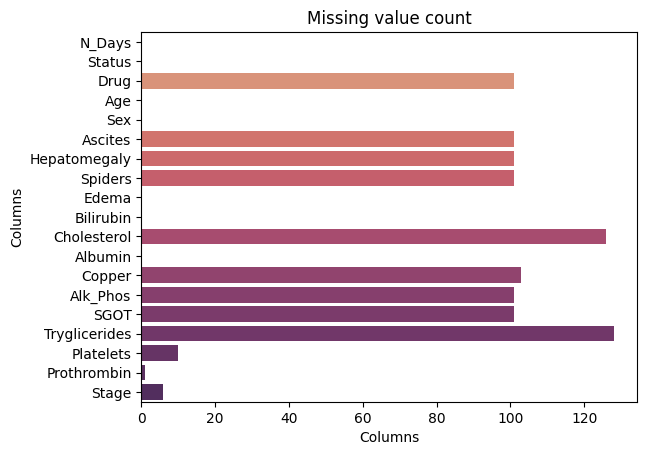

In [8]:
a = cir.isna().sum()
sns.barplot(y=a.index, x=a.values,palette="flare")
plt.title("Missing value count")
plt.xlabel("Columns")
plt.ylabel("Columns")

We got too many null values. Looking at number of rows, its not feasible to drop rows containing null values.

In [9]:
cir[cir["Stage"].isna()]

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
312,4062,C,NaN,60.041096,F,NaN,NaN,NaN,N,0.7,NaN,3.65,NaN,NaN,NaN,NaN,378.0,11.0,NaN
316,3030,C,NaN,62.043836,F,NaN,NaN,NaN,N,0.8,NaN,2.48,NaN,NaN,NaN,NaN,273.0,10.0,NaN
318,41,D,NaN,46.032877,F,NaN,NaN,NaN,N,5.0,NaN,2.93,NaN,NaN,NaN,NaN,260.0,10.4,NaN
321,2011,D,NaN,64.043836,F,NaN,NaN,NaN,N,1.1,NaN,3.69,NaN,NaN,NaN,NaN,139.0,10.5,NaN
333,466,D,NaN,56.038356,F,NaN,NaN,NaN,N,7.1,NaN,3.51,NaN,NaN,NaN,NaN,721.0,11.8,NaN
336,2286,D,NaN,56.038356,F,NaN,NaN,NaN,N,1.8,NaN,3.64,NaN,NaN,NaN,NaN,141.0,10.0,NaN


With too many missing values in rows where the target value is also missing, so lets drop rows with missing target value.

In [10]:
#drop rows with missing target(stage) value
cir.dropna(axis=0,subset=["Stage"],inplace=True)

In [11]:
cir["Stage"] = cir["Stage"].astype(int)

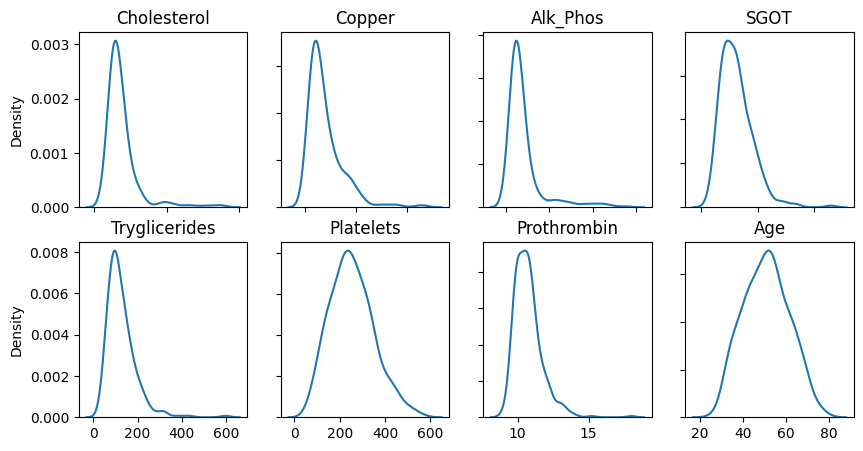

<Figure size 1200x800 with 0 Axes>

In [12]:
#checking data distributions for numerical features
#age doesn't have missing values, used here just to balance subplot
missing_nums = [["Cholesterol","Copper","Alk_Phos","SGOT"],["Tryglicerides","Platelets","Prothrombin","Age"]]
fig, axs = plt.subplots(2, 4,figsize=(10,5))
plt.figure(figsize=(12,8))
for i in range(2):
  for j in range(4):
    sns.kdeplot(cir,x=missing_nums[i][j], ax=axs[i,j])
    axs[i,j].label_outer()
    axs[i,j].set_xlabel('', fontsize=15)
    axs[i,j].set_title(missing_nums[i][j])
plt.show()

All the numerical features with missing values follows gaussian distributiom with some degree of skewness, so lets use median to impute missing values in those colums.
Also, some outlier can be seen, to fix skewness and outliers we will use log transformation(natural log being it a medical dataset)

In [13]:
#impute numerical values with median
numerical_columns = cir.select_dtypes(include=(['int64', 'float64'])).columns

for c in numerical_columns:
    if c!="Stage":cir[c] = np.log(cir[c]) #log transformation to remove outliers
    cir[c].fillna(cir[c].median(), inplace=True)

C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\913952786.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cir[c].fillna(cir[c].median(), inplace=True)
C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\913952786.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [14]:
categorical_columns = cir.select_dtypes(include=('object')).columns

for c in categorical_columns:
    cir[c].fillna(cir[c].mode().values[0], inplace=True)

C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\748688029.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cir[c].fillna(cir[c].mode().values[0], inplace=True)


Text(0.5, 1.0, 'Sex wise cirrhosis stages')

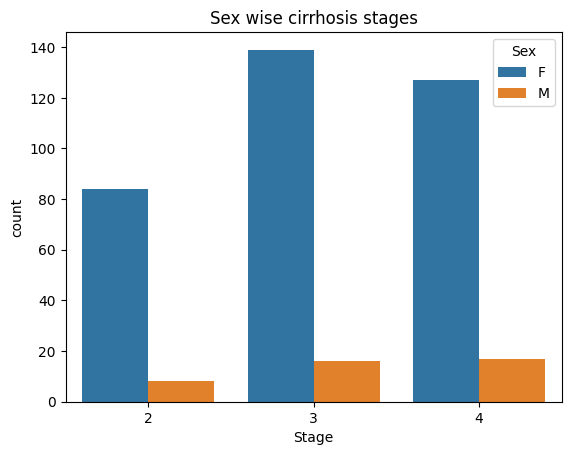

In [15]:
sns.countplot(x='Stage', hue='Sex', data=cir)
plt.title("Sex wise cirrhosis stages")

It's clear that female aremore prone to liver cirrhosis at any stage
One of the most common causes of liver cirrhosis is chronic alcohol consumption, and women may be more susceptible to alcohol-related liver damage than men. This is because women tend to have lower levels of an enzyme called alcohol dehydrogenase, which is involved in metabolizing alcohol. As a result, women may experience more severe liver damage from the same amount of alcohol consumption as men.

But due to almost same number of cases in all stages for both male and female, this feature might not be the best one to predict cirrhosis stage.

<Axes: xlabel='Stage', ylabel='count'>

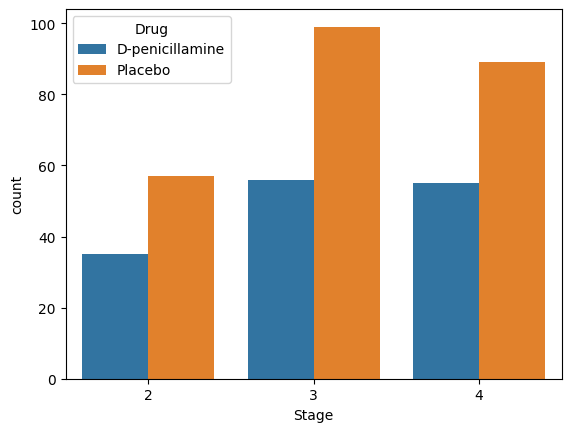

In [16]:
sns.countplot(x='Stage', hue='Drug', data=cir)

#Column Encoding



We have some categorical columns with string values.Many ML algorithms couldn't work with such values. So, lets use appropriate encoding to encode them. We should have used two types of encoding as below.
One hot Encoding : Drugs,Sex
Label Encoding : Status,Ascites, Hepatomegaly, Spiders, Edema

But, even in the column "Sex", some ordinal relation can be seen, so its also encoded using label encoder.
Also, the drug is label encoded based on their strength.
A placebo is a substance or treatment that has no therapeutic effect. Placebo drugs are often used in medical research to help determine the effectiveness of a new treatment by comparing it to the placebo.

Whereas D-penicillamine is used to balance excess body parameters like copper.

In [17]:
cir['Sex'] = cir['Sex'].replace({'M':0, 'F':1})
cir['Ascites'] = cir['Ascites'].replace({'N':0, 'Y':1})
cir['Drug'] = cir['Drug'].replace({'D-penicillamine':1, 'Placebo':0})
cir['Hepatomegaly'] = cir['Hepatomegaly'].replace({'N':0, 'Y':1})
cir['Spiders'] = cir['Spiders'].replace({'N':0, 'Y':1})
cir['Edema'] = cir['Edema'].replace({'N':0, 'Y':1, 'S':-1})
cir['Status'] = cir['Status'].replace({'C':0, 'CL':1, 'D':-1})

# cir['Stage'] = cir['Stage'].replace({2:0,3:1,4:2})
# cir['Stage'] = cir['Stage'].replace({1:0,2:1,3:2,4:3})

C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\3228476048.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cir['Sex'] = cir['Sex'].replace({'M':0, 'F':1})
C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\3228476048.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cir['Ascites'] = cir['Ascites'].replace({'N':0, 'Y':1})
C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\3228476048.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

## Dataset balancing

First, we will check number of samples in our dataset for each stage of liver cirrhosis.

In [18]:
def plot_target_count(data):
  """Function to plot number of samples in each class"""

  plt.figure(figsize=(4,4))
  counts = data.value_counts()

  plt.bar(x = counts.index, height = counts, color = 'orange')
  plt.xticks(rotation = 90)
  plt.title('Target Counts')
  plt.xlabel('Stages')
  plt.ylabel('Counts')
  plt.xticks([2,3,4], ['Stage 2', 'Stage 3', 'Stage 4'], rotation = 0)
  plt.show()

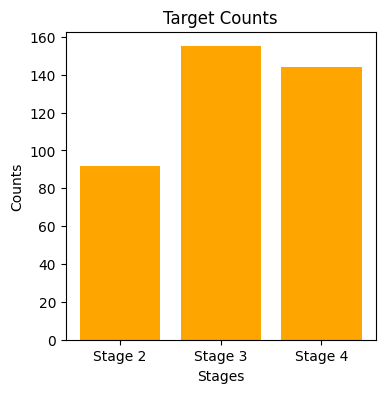

In [19]:
plot_target_count(cir["Stage"])

The dataset is  imbalanced with less number of rows for earlier stage of cirrhosis. We will perform oversampling using SMOTE(Synthetic Minority Oversampling Technique).

Before performing oversamling we will split our existing dataset into train and test set. We will use 80-20 split for train and test set.

In [20]:
# separate features and target
X = cir.drop(['Status', 'Stage'], axis=1)
y = cir['Stage']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 23)

In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
#Using Smote for upsampling
sm = SMOTE(k_neighbors = 3)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [24]:
X_train.shape,y_train.shape

((363, 17), (363,))

# Feature Scaling

As we saw before, the numerical columns have varying range, so we will perform feature selection to scale them.

We will experiment with two kind of scaler: StandardScaler and MinMax Scaler.

In [25]:
# Using standard Scaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# # Using MinMax Scaler
# scaler = MinMaxScaler()
# scaler.fit(X_train)
# X_train = scaler.transform(X_train)
# X_test = scaler.transform(X_test)

## Feature Selection
 Our dataset
has a comparatively more number of features considering the number of records. So, in order to
select the best feature, we will use a statistical method called the ANOVA test.

In [27]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [28]:
best = SelectKBest( score_func = f_classif, k = 12)
best.fit(X_train,y_train)

,score_func,<function f_c...00139DFDF28E0>
,k,12


In [29]:
best_cols = best.get_support(indices=True)
best_cols

array([ 0,  2,  4,  5,  6,  8,  9, 10, 11, 14, 15, 16])

In [30]:
best_train = X_train[:,best_cols]
best_test = X_test[:,best_cols]

In [31]:
scores = best.scores_
pvalues = best.pvalues_
cols = X.columns
for idx in range(X.shape[1]):
  print(cols[idx],scores[idx])

N_Days 35.58064240733676
Drug 0.4312354312354322
Age 8.753311360137573
Sex 0.2756508422664627
Ascites 12.42394504416091
Hepatomegaly 28.639714094259656
Spiders 13.156934306569326
Edema 0.2730136506825339
Bilirubin 15.6931810963989
Cholesterol 4.70575180438692
Albumin 27.598188642373117
Copper 11.984431933776413
Alk_Phos 0.02908261394516537
SGOT 1.4469442198797429
Tryglicerides 4.140836244481557
Platelets 13.336089515504117
Prothrombin 25.866998516522333


C:\Users\SREE CHARITHA\AppData\Local\Temp\ipykernel_13264\2725217572.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=cols,x=scores,palette="flare")


Text(0, 0.5, 'Features')

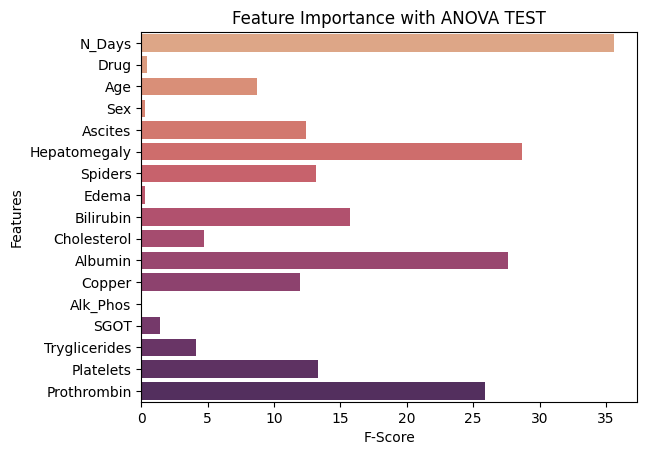

In [32]:
sns.barplot(y=cols,x=scores,palette="flare")
plt.title("Feature Importance with ANOVA TEST")
plt.xlabel("F-Score")
plt.ylabel("Features")

## Setup MLFlow

In [33]:
%pip install mlflow
!databricks configure --host https://community.cloud.databricks.com/

Note: you may need to restart the kernel to use updated packages.


'databricks' is not recognized as an internal or external command,
operable program or batch file.


In [34]:
%env ML_FLOW_EXP=<place you databrick experiment uri string here>

env: ML_FLOW_EXP=<place you databrick experiment uri string here>


In [35]:
import os
import mlflow

# --- EDIT THESE VALUES ---
# 1. Your Databricks workspace URL (found in your browser's address bar).
db_host = "https://<your-workspace-name>.cloud.databricks.com/"

# 2. Your Databricks personal access token (starts with "dapi").
db_token = "dapi<your-personal-access-token>"

# 3. The name of your MLflow experiment. It can be a new or existing name.
experiment_name = "my_new_experiment"
# --- END EDIT SECTION ---

# Set the authentication and host details. This makes the script self-contained.
os.environ["MLFLOW_TRACKING_URI"] = db_host
os.environ["MLFLOW_TRACKING_TOKEN"] = db_token

try:
    # This line now directly uses the variable you set above,
    # so there is no KeyError.
    mlflow.set_experiment(experiment_name)
    print(f"Successfully set MLflow experiment to '{experiment_name}'.")

    # Start a run to test that everything is working
    with mlflow.start_run():
        mlflow.log_param("param1", "test")
        mlflow.log_metric("accuracy", 0.99)
        print("Logged a test run to Databricks.")
        
except Exception as e:
    print("An error occurred. Check your host and token details.")
    print(f"Error: {e}")

An error occurred. Check your host and token details.
Error: API request to https://<your-workspace-name>.cloud.databricks.com/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPSConnectionPool(host='%3cyour-workspace-name%3e.cloud.databricks.com', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=my_new_experiment (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000139E27A0410>: Failed to resolve '%3cyour-workspace-name%3e.cloud.databricks.com' ([Errno 11001] getaddrinfo failed)"))


In [36]:
#pip install mlflow

In [37]:
import mlflow

# Correctly set the tracking URI for a local file system.
# The `file:///` prefix is required.
mlflow.set_tracking_uri("file:///C:/Users/SREE CHARITHA/OneDrive/sure-vs")

# Now, set the experiment name.
experiment_name = "my_local_ml_experiment"
mlflow.set_experiment(experiment_name)

# Now your logging code will work
with mlflow.start_run():
    mlflow.log_param("param1", 1)
    mlflow.log_metric("metric1", 0.5)

print("MLflow run logged successfully to local directory!")

2025/08/28 22:29:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



MLflow run logged successfully to local directory!


In [38]:
import os
import mlflow
mlflow.set_tracking_uri("databricks")
#mlflow.set_experiment(os.environ['ML_FLOW_EXP'])

In [39]:
#function to track experiment results with mlflow
def mlflow_track(model,exp_name,train_scores,test_scores):
  #set name of experiment
  params = model.get_params()#

  with mlflow.start_run(run_name=exp_name):
    mlflow.log_metric("recall_train", train_scores[0])
    mlflow.log_metric("precision_train", train_scores[1])
    mlflow.log_metric("f1_train", train_scores[2])
    mlflow.log_metric("accuracy_train", train_scores[3])
    mlflow.log_metric("recall_test", test_scores[0])
    mlflow.log_metric("precision_test", test_scores[1])
    mlflow.log_metric("f1_test", test_scores[2])
    mlflow.log_metric("accuracy_test", test_scores[3])
    mlflow.log_params(params)

In [40]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, recall_score, precision_score,classification_report

In [41]:
def evaluate_model(y_train,y_pred_train,y_test,y_pred_test):
  print("-"*30,"FOR TRAIN SET","-"*30)
  recall_train = recall_score(y_train,y_pred_train,average="macro")
  precision_train = precision_score(y_train,y_pred_train,average="macro")
  f1_train = f1_score(y_train,y_pred_train,average="macro")
  accuracy_train = accuracy_score(y_train,y_pred_train)
  rep_train = classification_report(y_train,y_pred_train)
  print(rep_train)
  
  print("-"*30,"FOR TEST SET","-"*30)
  recall_test = recall_score(y_test,y_pred_test,average="macro")
  precision_test = precision_score(y_test,y_pred_test,average="macro")
  f1_test = f1_score(y_test,y_pred_test,average="macro")
  accuracy_test = accuracy_score(y_test,y_pred_test)
  rep_test = classification_report(y_test,y_pred_test)
  print(rep_test)
  return (recall_train,precision_train,f1_train,accuracy_train), (recall_test,precision_test,f1_test,accuracy_test)

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,BaggingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [43]:
import mlflow

mlflow.set_tracking_uri("file:///C:/Users/SREE CHARITHA/OneDrive/sure-vs")
mlflow.set_experiment("my_local_ml_experiment")

<Experiment: artifact_location='file:///C:/Users/SREE CHARITHA/OneDrive/sure-vs/381332795727976412', creation_time=1755879088094, experiment_id='381332795727976412', last_update_time=1755879088094, lifecycle_stage='active', name='my_local_ml_experiment', tags={}>

In [44]:
#log_reg = LogisticRegression(max_iter=500,random_state=28)
#log_reg.fit(best_train, y_train)

#log_pred = log_reg.predict(best_test)
#log_pred_train = log_reg.predict(best_train)

#train_scores, test_scores = evaluate_model(y_train, log_pred_train, y_test, log_pred)
#mlflow_track(log_reg, "logistic_reg-500iter", train_scores, test_scores)

In [45]:
import mlflow
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    classification_report,
)

# --- 1. DEFINE YOUR DATA (PLACEHOLDER) ---
# You need to have your data defined for the code to run.
# Replace this with your actual data loading and preprocessing.
# This is a placeholder to make the code runnable.
X_train = np.random.rand(100, 5)
y_train = np.random.randint(0, 2, 100)
X_test = np.random.rand(50, 5)
y_test = np.random.randint(0, 2, 50)
best_train = X_train
best_test = X_test


# --- 2. DEFINE YOUR EVALUATION FUNCTION ---
def evaluate_model(y_train, y_pred_train, y_test, y_pred_test):
    print("-" * 30, "FOR TRAIN SET", "-" * 30)
    recall_train = recall_score(y_train, y_pred_train, average="macro")
    precision_train = precision_score(y_train, y_pred_train, average="macro")
    f1_train = f1_score(y_train, y_pred_train, average="macro")
    accuracy_train = accuracy_score(y_train, y_pred_train)
    rep_train = classification_report(y_train, y_pred_train)
    print(rep_train)

    print("-" * 30, "FOR TEST SET", "-" * 30)
    recall_test = recall_score(y_test, y_pred_test, average="macro")
    precision_test = precision_score(y_test, y_pred_test, average="macro")
    f1_test = f1_score(y_test, y_pred_test, average="macro")
    accuracy_test = accuracy_score(y_test, y_pred_test)
    rep_test = classification_report(y_test, y_pred_test)
    print(rep_test)

    return (
        (recall_train, precision_train, f1_train, accuracy_train),
        (recall_test, precision_test, f1_test, accuracy_test),
    )


# --- 3. CONFIGURE MLFLOW (LOCAL) ---
# This ensures MLflow saves runs to a local folder named 'mlruns'.
# Do NOT use 'mlflow.set_tracking_uri("databricks")'.
mlflow.set_experiment("my_local_ml_experiment")


# --- 4. RUN YOUR MODEL & LOG WITH MLFLOW ---
with mlflow.start_run(run_name="Logistic Regression"):
    log_reg = LogisticRegression(max_iter=500, random_state=28)
    log_reg.fit(best_train, y_train)

    log_pred = log_reg.predict(best_test)
    log_pred_train = log_reg.predict(best_train)

    # Call the evaluation function
    train_scores, test_scores = evaluate_model(
        y_train, log_pred_train, y_test, log_pred
    )

    # Log metrics with MLflow
    mlflow.log_param("max_iter", 500)
    mlflow.log_metric("train_accuracy", train_scores[3])
    mlflow.log_metric("test_accuracy", test_scores[3])

    print("\nSuccessfully logged Logistic Regression run.")

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.57      0.30      0.39        44
           1       0.60      0.82      0.69        56

    accuracy                           0.59       100
   macro avg       0.58      0.56      0.54       100
weighted avg       0.58      0.59      0.56       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.75      0.19      0.31        31
           1       0.40      0.89      0.56        19

    accuracy                           0.46        50
   macro avg       0.58      0.54      0.43        50
weighted avg       0.62      0.46      0.40        50


Successfully logged Logistic Regression run.


In [46]:
dt = DecisionTreeClassifier(criterion="log_loss",max_depth=50,random_state=20)
dt.fit(best_train, y_train)

dt_pred = dt.predict(best_test)
dt_pred_train = dt.predict(best_train)

train_scores,test_scores = evaluate_model(y_train,dt_pred_train,y_test,dt_pred)
mlflow_track(log_reg,"dtree",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        56

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.50      0.42      0.46        31
           1       0.25      0.32      0.28        19

    accuracy                           0.38        50
   macro avg       0.38      0.37      0.37        50
weighted avg       0.41      0.38      0.39        50



In [47]:
rf = RandomForestClassifier(n_estimators=120,criterion="log_loss",max_depth=10,min_samples_leaf=4,random_state=20)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_pred_train = rf.predict(X_train)

train_scores,test_scores = evaluate_model(y_train,rf_pred_train,y_test,rf_pred)
mlflow_track(rf,"rf-log_loss",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        44
           1       0.95      0.96      0.96        56

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.44      0.26      0.33        31
           1       0.28      0.47      0.35        19

    accuracy                           0.34        50
   macro avg       0.36      0.37      0.34        50
weighted avg       0.38      0.34      0.34        50



In [48]:
rf = RandomForestClassifier(n_estimators=25,criterion="log_loss",max_depth=25,min_samples_leaf=4,random_state=20)
# rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_pred_train = rf.predict(X_train)

train_scores,test_scores = evaluate_model(y_train,rf_pred_train,y_test,rf_pred)
mlflow_track(rf,"rf2",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        44
           1       0.93      0.98      0.96        56

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.64      0.45      0.53        31
           1       0.39      0.58      0.47        19

    accuracy                           0.50        50
   macro avg       0.51      0.52      0.50        50
weighted avg       0.54      0.50      0.51        50



In [49]:
bag = BaggingClassifier(rf,bootstrap_features=True,random_state=22)
bag.fit(X_train, y_train)

bag_pred = bag.predict(X_test)
bag_pred_train = bag.predict(X_train)

train_scores,test_scores = evaluate_model(y_train,bag_pred_train,y_test,bag_pred)
mlflow_track(bag,"bagging-rf",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.96      0.61      0.75        44
           1       0.76      0.98      0.86        56

    accuracy                           0.82       100
   macro avg       0.86      0.80      0.80       100
weighted avg       0.85      0.82      0.81       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.40      0.19      0.26        31
           1       0.29      0.53      0.37        19

    accuracy                           0.32        50
   macro avg       0.34      0.36      0.32        50
weighted avg       0.36      0.32      0.30        50



In [50]:
bag_fs = BaggingClassifier(rf,bootstrap_features=True,random_state=22)
bag_fs.fit(best_train, y_train)

bag_fs_pred = bag_fs.predict(best_test)
bag_fs_pred_train = bag_fs.predict(best_train)

train_scores,test_scores = evaluate_model(y_train,bag_fs_pred_train,y_test,bag_fs_pred)
mlflow_track(bag,"bagging-rf featSel",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.96      0.61      0.75        44
           1       0.76      0.98      0.86        56

    accuracy                           0.82       100
   macro avg       0.86      0.80      0.80       100
weighted avg       0.85      0.82      0.81       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.40      0.19      0.26        31
           1       0.29      0.53      0.37        19

    accuracy                           0.32        50
   macro avg       0.34      0.36      0.32        50
weighted avg       0.36      0.32      0.30        50



In [51]:
ada = AdaBoostClassifier(n_estimators=50,random_state=20)
ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
ada_pred_train = ada.predict(X_train)

train_scores,test_scores = evaluate_model(y_train,ada_pred_train,y_test,ada_pred)
mlflow_track(ada,"ada boost1",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        44
           1       0.91      0.86      0.88        56

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.58      0.45      0.51        31
           1       0.35      0.47      0.40        19

    accuracy                           0.46        50
   macro avg       0.46      0.46      0.45        50
weighted avg       0.49      0.46      0.47        50



In [52]:
ada = AdaBoostClassifier(random_state=28)
ada.fit(best_train, y_train)

ada_pred = ada.predict(best_test)
ada_pred_train = ada.predict(best_train)

train_scores,test_scores  = evaluate_model(y_train,ada_pred_train,y_test,ada_pred)
mlflow_track(ada,"ada boost2- featSel",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        44
           1       0.91      0.86      0.88        56

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.58      0.45      0.51        31
           1       0.35      0.47      0.40        19

    accuracy                           0.46        50
   macro avg       0.46      0.46      0.45        50
weighted avg       0.49      0.46      0.47        50



In [53]:
svm = SVC(kernel="rbf")
svm.fit(best_train, y_train)

svm_pred = svm.predict(best_test)
svm_pred_train = svm.predict(best_train)

train_scores,test_scores = evaluate_model(y_train,svm_pred_train,y_test,svm_pred)
mlflow_track(svm,"svm-feat sel",train_scores,test_scores)

------------------------------ FOR TRAIN SET ------------------------------
              precision    recall  f1-score   support

           0       0.74      0.32      0.44        44
           1       0.63      0.91      0.74        56

    accuracy                           0.65       100
   macro avg       0.68      0.61      0.59       100
weighted avg       0.68      0.65      0.61       100

------------------------------ FOR TEST SET ------------------------------
              precision    recall  f1-score   support

           0       0.89      0.26      0.40        31
           1       0.44      0.95      0.60        19

    accuracy                           0.52        50
   macro avg       0.66      0.60      0.50        50
weighted avg       0.72      0.52      0.48        50



Manual hypermeter tuning was done in most of these models.

## CONCLUSION

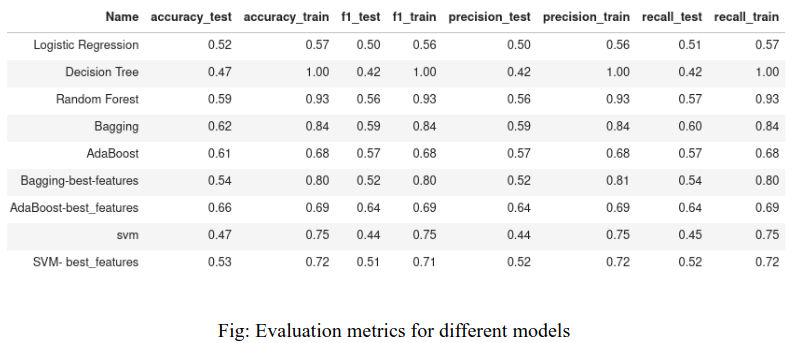

The results of our liver cirrhosis stage prediction models were not very promising, with the best recall score of 69% on the train test and 64% for the test set with AdaBoost with decision tree model. Our model was trained on a dataset of 369 records, with each patient's data including age,
gender and biomarkers from liver function test results.We used a variety of machine learning algorithms, including decision trees, random forests, bagging, adaboosting and support vector machines to build our prediction model. These results were obtained with only 3 stages after dropping records for stage 1 which is a normal healthy liver. 

The best obtained for stage 2, stage 3 and stage 4 are 56%,68% and 69% respectively. The higher
recall for irreversible state is a good point, but the results are not sufficient to be used in a real
world setting. The later stage of liver cirrhosis can be diagnosed easily with simple tests. So, the
automated predictive system must be capable of detecting them at an earlier stage too.
For this, we need to collect more consistent data which contains cases of earlier stage of cirrhosis
too. Also, the use of more complex models like Neural Networks would definitely improve the
results.